# This code can be used to perform sanity checks that preprocessing was done correctly
### It checks the following:
1. Plots a FC matrix for visual check
2. Higher within than between FC for the DMN
3. Anti correlation between high and low attention networks

In [1]:
PRJ_DIR = '/project/mdrosenberg/IG/preproc_test_bball'
task = 'view' #task is required
run = '01' #run is optional, if you do not want run just put '' 

In [2]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os.path as osp

In [4]:
#TO DO: check that this is correct - why do we get double FC, and do i need to z score? 

def load_netcc(path,roi_names=None):
 sfc = pd.read_csv(path,sep='\t',comment='#', header=0)
 sfc = sfc.drop(0,axis=0)
 sfc = sfc.head(len(sfc.columns))
 sfc.index = sfc.columns
 if roi_names is not None:
  sfc.index = roi_names
  sfc.columns = roi_names
 return sfc

In [5]:
def get_sub_list(DATA_DIR):
    import os

    # Get the list of files in the current directory
    files = os.listdir(DATA_DIR)
    
    # Sort the files by modification time
    sorted_files = sorted(files)
    
    sub_list = []

    for i, filename in enumerate(sorted_files):
        if filename[0:3] == 'sub':
            sub = filename
            sub_folder = osp.join(DATA_DIR, filename)
            if os.path.isdir(sub_folder):
                ses_count = 0
                ses_nums = []

                for sub_filename in os.listdir(sub_folder):
                    if sub_filename[0:3] == 'ses':
                        ses_count += 1
                        ses_nums.append(sub_filename)

                for s in range(ses_count):
                    sub_list.append((sub,ses_nums[s]))
    return sub_list

In [6]:
sub_list = get_sub_list('/project/mdrosenberg/IG/preproc_test_bball/derivatives/preprocessed/')

# 1. Plot FC matrix for visual QC 
Select the subject first

Note: currently this is not sorting the matrix by network so the plot doesnt show anything

In [ ]:
sub = 'sub-01'
ses = 'ses-01'

In [ ]:
#load relevant files 
network_labels_path = '/project/mdrosenberg/IG/preprocessing/masks/Shen_network_labels.pkl'
with open(network_labels_path, 'rb') as file:
            network_labels = pickle.load(file)['Shen_network_labels']

canonical_mask_path = '/project/mdrosenberg/IG/preprocessing/masks/canonical_mask.pkl'
with open(canonical_mask_path, 'rb') as file:
            canonical_mask = pickle.load(file)['canonical_mask']

network_names = ['Medial frontal','Frontoparietal','Default mode','Subcortical-cerebellum','Motor','Visual I','Visual II','Visual association']

In [7]:
netcc_path = (f'{PRJ_DIR}/derivatives/preprocessed/{sub}/{ses}/4_{sub}_{ses}_task-{task}_run-{run}_LPI_000.netcc')
FC = load_netcc(netcc_path)

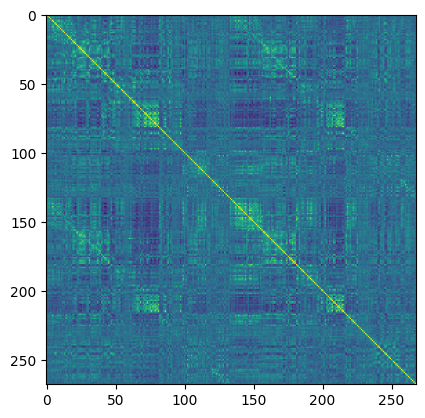

In [8]:
#TO DO: sort by network and make plot formal 
plt.imshow(FC)

# 2. Greater within than between FC for DMN and FP

In [10]:
def summarize_net_con(FC, canonical_mask, net1, net2):
    #get indices
    ind = canonical_mask[net1,net2]

    #select networks from FC
    net_FC = ind*FC

    #create plot of network FC to check
    #plt.imshow(net_FC)

    num_nodes = ind.sum().sum()
    avg_net_FC = net_FC.sum().sum()/num_nodes

    return avg_net_FC
    

In [11]:
store = pd.DataFrame(columns=['DMN-DMN','DMN-FP'])
row = 0

for sub, scan in sub_list:
    netcc_path = (f'{PRJ_DIR}/derivatives/preprocessed/{sub}/{ses}/4_{sub}_{ses}_task-{task}_run-{run}_LPI_000.netcc')
    FC = load_netcc(netcc_path)

    DMN_DMN = summarize_net_con(FC, canonical_mask, 2, 2)
    DMN_FP = summarize_net_con(FC, canonical_mask, 2, 1)

    store.loc[row,'DMN-DMN'] = DMN_DMN
    store.loc[row,'DMN-FP'] = DMN_FP
    row += 1


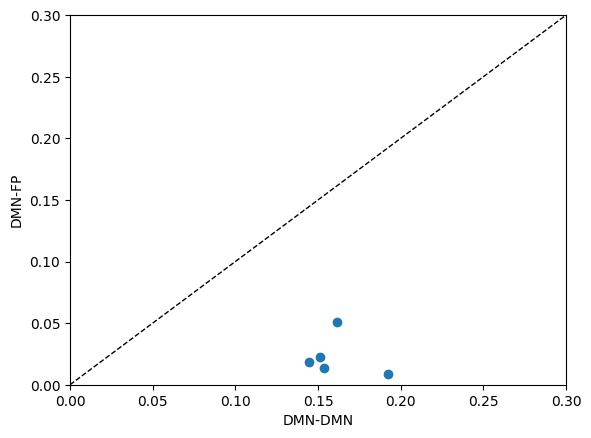

In [12]:
plt.scatter(store['DMN-DMN'], store['DMN-FP'])
plt.xlabel('DMN-DMN')
plt.ylabel('DMN-FP')

ax = plt.gca()
ax.set_xlim([0,0.3])
ax.set_ylim([0,0.3])

x_vals = [0, 1]  # Identity line range
y_vals = [0, 1]  # Identity line values

# Add the identity line
plt.plot(x_vals, y_vals, transform=plt.gca().transAxes, color='k', linestyle='--', linewidth=1)

### To confirm that this is correct: All dopts in the plot above should be BELOW the identity line

# 3. Anti-correlation between high and low attention networks

In [13]:
#load relevant files 
saCPM = '/project/mdrosenberg/IG/preprocessing/masks/saCPM.pkl'
with open(saCPM, 'rb') as file:
            high_attention_mask = pickle.load(file)['high_attention_mask']

with open(saCPM, 'rb') as file:  
            low_attention_mask = pickle.load(file)['low_attention_mask']

In [14]:
atten = pd.DataFrame(columns=['high_atten','low_atten'])
row = 0

for sub, scan in sub_list:
    netcc_path = (f'{PRJ_DIR}/derivatives/preprocessed/{sub}/{ses}/4_{sub}_{ses}_task-{task}_run-{run}_LPI_000.netcc')
    FC = load_netcc(netcc_path)

    #high
    high_FC = high_attention_mask*FC
    high = high_FC.sum().sum()/(high_attention_mask.sum().sum())

    #low
    low_FC = low_attention_mask*FC
    low = low_FC.sum().sum()/(low_attention_mask.sum().sum())
    
    atten.loc[row,'high_atten'] = high
    atten.loc[row,'low_atten'] = low
    row += 1

,high_atten,low_atten
high_atten,1.000000,-0.589211
low_atten,-0.589211,1.000000


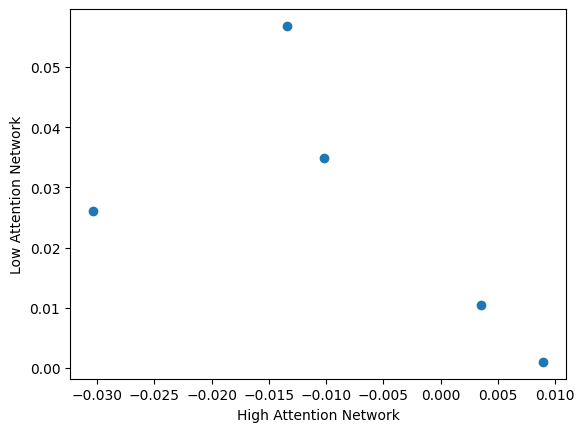

In [31]:
plt.scatter(atten['high_atten'], atten['low_atten'])
plt.xlabel('High Attention Network')
plt.ylabel('Low Attention Network')

atten.corr()


### To confirm this result is good, the correlation between high and low should be negative 